## Import Libraries

In [6]:
import numpy as np
import cv2
import os
from scipy.spatial import distance
import matplotlib.pyplot as plt
import imageio
import matplotlib.cm

## Dataloader

In [7]:
class Dataloader:
    def __init__(self, data_path):
        self.root_path = data_path
    def load_img(self):
        imgs = []
        for i in range(2):
            img_path = os.path.join(self.root_path, f'image{i + 1}.png')
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            imgs.append(img)
        return imgs

## Spectral Clustering

In [8]:
class SpectralClustering:
	def __init__(self, img_num, gamma_s, gamma_c, K = 2, cut_mode = 'normalize', k_means_plus_plus = False):
		assert cut_mode in ['normalize', 'ratio']
		self.gamma_s, self.gamma_c = gamma_s, gamma_c
		self.K = K
		self.img_num = img_num
		self.dataloader = Dataloader('./')
		self.img = self.dataloader.load_img()[img_num - 1]
		self.cluster_img = []
		self.cut_mode = cut_mode
		self.init = k_means_plus_plus
	def kernel(self):
		x, y = np.meshgrid(range(100), range(100), indexing='ij')
		coordinates = np.column_stack((x.ravel(), y.ravel()))
		spatial_square_norm = distance.cdist(coordinates, coordinates, metric='sqeuclidean')
		flatten_img = self.img.reshape(-1, 3)
		color_square_norm = distance.cdist(flatten_img, flatten_img, metric='sqeuclidean')
		return np.exp(-self.gamma_s * spatial_square_norm) * np.exp(-self.gamma_c * color_square_norm)
	def get_laplacian(self):
		K = self.kernel()
		D = np.diag(K.sum(axis=1))
		L = D - K
		if self.cut_mode == 'normalize':
			D_inv_sqrt = np.diag(1 / np.sqrt(np.diag(D)))
			L = D_inv_sqrt @ L @ D_inv_sqrt
		return L
	def spectral_clustering(self, max_iter = 200):
		L = self.get_laplacian()
		eigen_values, eigen_vectors = self.compute_and_save_eig(L, f"eig_img_{self.img_num}_{self.cut_mode}.npz")
		sorted_indices = np.argsort(eigen_values)
		sorted_eigen_values = eigen_values[sorted_indices]
		sorted_eigen_vectors = eigen_vectors[:, sorted_indices]
		U = sorted_eigen_vectors[:,:self.K]
		if self.cut_mode == 'normalize':
			U = U / np.linalg.norm(U, axis=1, keepdims=True)
		pixel_labels = self.kmeans(U)
	def kmeans(self, U, max_iter = 200):
		pixel_labels = np.zeros((10000, 1), dtype=np.int32)
		centroids_idx = self.get_init_centroids(U)
		centroids = U[centroids_idx, :]
		for i in range(max_iter):
			distances = np.linalg.norm(U[:, np.newaxis] - centroids, axis=2)
			new_pixel_labels = np.argmin(distances, axis=1)
			new_centroids = np.array([U[new_pixel_labels == j].mean(axis=0) for j in range(self.K)])
			if np.all(pixel_labels == new_pixel_labels):
				break
			centroids = new_centroids
			pixel_labels = new_pixel_labels
			self.save_cluster(pixel_labels)
		self.plot_eigenspace(U, pixel_labels)
		return pixel_labels
	def get_init_centroids(self, U):
		if not self.init:
			return np.random.randint(0, 10000, self.K, dtype=int).tolist()
		else:
			centroids = []
			first_centroid = np.random.randint(0, 10000, dtype=int)
			centroids.append(first_centroid)
			for _ in range(1, self.K):
				distances = np.array([min(np.linalg.norm(data - c)**2 for c in centroids) for data in U])
				prob = distances / np.sum(distances)
				next_centroid = np.random.choice(10000, p=prob)
				centroids.append(next_centroid)
			return centroids
	def save_cluster(self, labels):
		reshaped_labels = labels.reshape(100, 100, 1)
		reshaped_labels = (255 // self.K * reshaped_labels).astype(np.uint8)
		self.cluster_img.append(reshaped_labels)
	def make_gif(self):
		gif_path = f'./spectral_image{self.img_num}_{self.cut_mode}_{self.K}.gif'
		if self.init:
			gif_path = f'./spectral_image{self.img_num}_{self.cut_mode}_{self.K}_plus.gif'
		for i in range(len(self.cluster_img)):
			self.cluster_img[i] = cv2.applyColorMap(self.cluster_img[i], 2)
		imageio.mimsave(gif_path, self.cluster_img, duration=10)
		print(f'Converge in {len(self.cluster_img)} ierations')
	def plot_eigenspace(self, U, labels):
		colormap = plt.colormaps['tab10']
		colors = [colormap(i / self.K) for i in range(self.K)]
		height = 3 * self.K
		fig, axs = plt.subplots(self.K, 1, figsize=(10, height))
		for i in range(self.K):
			colors = [colormap(label) for label in labels]
			axs[i].scatter(range(U.shape[0]), U[:, i], c=colors, s=2)
			axs[i].set_title(f"Values of Eigenvector {i + 1}")
			axs[i].set_xlabel("Data Point Index")
			axs[i].set_ylabel(f"Value in Eigenspace of Eigenvector {i + 1}")
			axs[i].set_xlim(0, 10000)
		plt.tight_layout()
		plt.savefig( f'./eigenspace_image{self.img_num}_{self.cut_mode}_{self.K}.png',
					dpi=300, bbox_inches='tight')
		plt.close(fig)
		fig, ax = plt.subplots(1, 1, figsize=(4, 4))
		colors = [colormap(label) for label in labels]
		scatter = ax.scatter(U[:, 0], U[:, 1], c=colors, s=2)
		ax.set_title("2D-Eigenvector")
		ax.set_xlabel("Eigenvector 1")
		ax.set_ylabel("Eigenvector 2")
	def compute_and_save_eig(self, L, filename):
		if os.path.exists(filename):
			print("Loading eigenvalues and eigenvectors from file...")
			data = np.load(filename)
			eigenvalues = data['eigenvalues']
			eigenvectors = data['eigenvectors']
		else:
			print("Calculating eigenvalues and eigenvectors...")
			eigenvalues, eigenvectors = np.linalg.eig(L)
			np.savez(filename, eigenvalues=eigenvalues, eigenvectors=eigenvectors)
		return eigenvalues, eigenvectors
	

## Experiment

Loading eigenvalues and eigenvectors from file...
Loading eigenvalues and eigenvectors from file...


/home/hsiung/anaconda3/envs/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/hsiung/anaconda3/envs/3.11/lib/python3.11/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


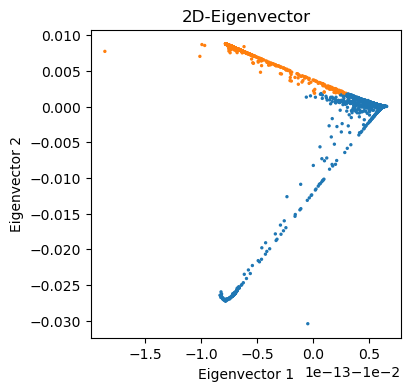

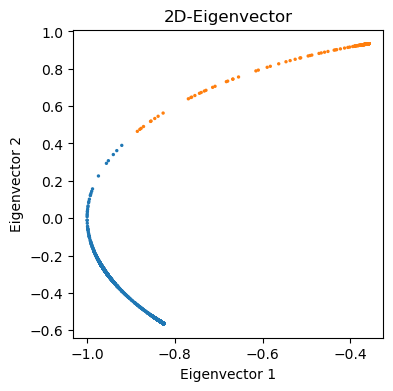

In [11]:
part_1_img1 = SpectralClustering(1, 1e-3, 1e-3, K = 2, cut_mode = 'ratio', k_means_plus_plus=False)
part_1_img1.spectral_clustering()
part_1_img2 = SpectralClustering(1, 1e-3, 1e-3, K = 2, cut_mode = 'normalize', k_means_plus_plus=False)
part_1_img2.spectral_clustering()

In [12]:
part_1_img1.make_gif()
part_1_img2.make_gif()

Converge in 6 ierations
Converge in 12 ierations


Loading eigenvalues and eigenvectors from file...
Loading eigenvalues and eigenvectors from file...
Converge in 31 ierations
Converge in 18 ierations


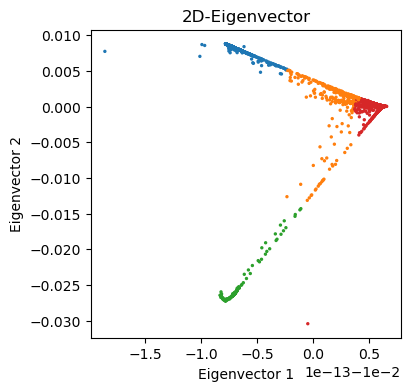

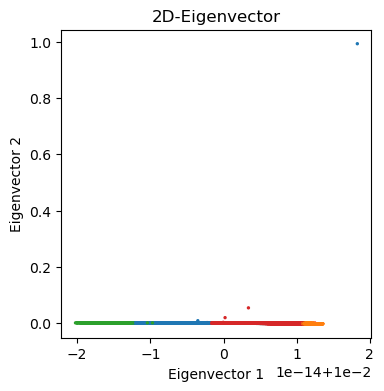

In [14]:
part_2_img1 = SpectralClustering(1, 1e-3, 1e-3, K = 4, cut_mode = 'ratio', k_means_plus_plus=False)
part_2_img1.spectral_clustering()
part_2_img2 = SpectralClustering(2, 1e-3, 1e-3, K = 4, cut_mode = 'ratio', k_means_plus_plus=False)
part_2_img2.spectral_clustering()
part_2_img1.make_gif()
part_2_img2.make_gif()

Loading eigenvalues and eigenvectors from file...
Loading eigenvalues and eigenvectors from file...
Converge in 7 ierations
Converge in 7 ierations


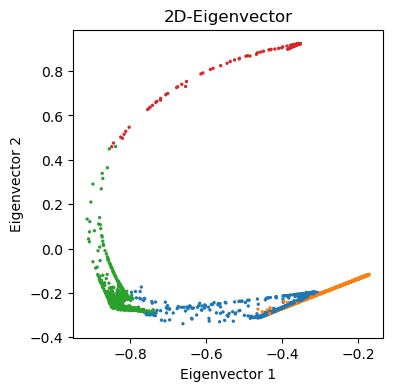

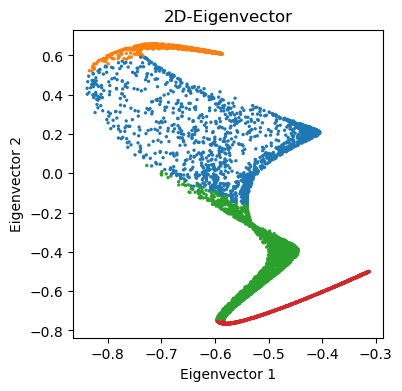

In [16]:
part_2_img1 = SpectralClustering(1, 1e-3, 1e-3, K = 4, cut_mode = 'normalize', k_means_plus_plus=False)
part_2_img1.spectral_clustering()
part_2_img2 = SpectralClustering(2, 1e-3, 1e-3, K = 4, cut_mode = 'normalize', k_means_plus_plus=False)
part_2_img2.spectral_clustering()
part_2_img1.make_gif()
part_2_img2.make_gif()

Loading eigenvalues and eigenvectors from file...
Loading eigenvalues and eigenvectors from file...
Converge in 4 ierations
Converge in 26 ierations


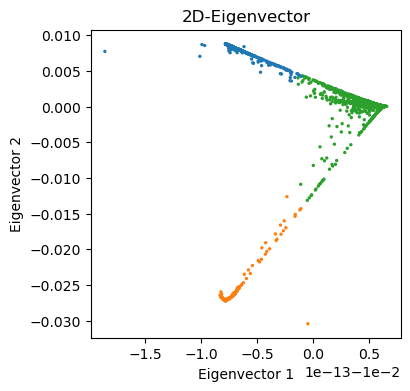

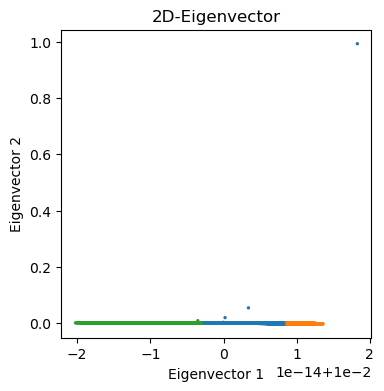

In [21]:
part_3_img1 = SpectralClustering(1, 1e-3, 1e-3, K = 3, cut_mode = 'ratio', k_means_plus_plus=True)
part_3_img1.spectral_clustering()
part_3_img2 = SpectralClustering(2, 1e-3, 1e-3, K = 3, cut_mode = 'ratio', k_means_plus_plus=True)
part_3_img2.spectral_clustering()
part_3_img1.make_gif()
part_3_img2.make_gif()

Loading eigenvalues and eigenvectors from file...


/home/hsiung/anaconda3/envs/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/hsiung/anaconda3/envs/3.11/lib/python3.11/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


Loading eigenvalues and eigenvectors from file...
Converge in 2 ierations
Converge in 12 ierations


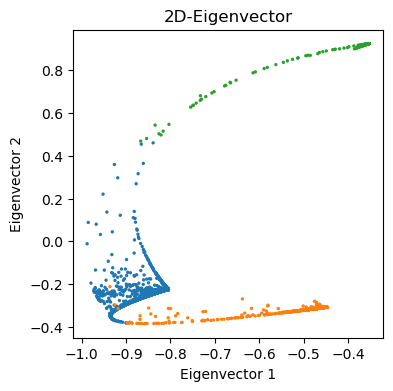

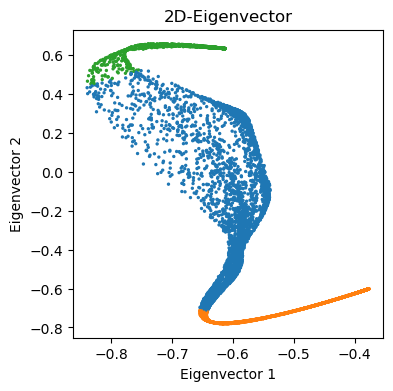

In [18]:
part_3_img1 = SpectralClustering(1, 1e-3, 1e-3, K = 3, cut_mode = 'normalize', k_means_plus_plus=True)
part_3_img1.spectral_clustering()
part_3_img2 = SpectralClustering(2, 1e-3, 1e-3, K = 3, cut_mode = 'normalize', k_means_plus_plus=True)
part_3_img2.spectral_clustering()
part_3_img1.make_gif()
part_3_img2.make_gif()